
=== VAL ===
MAE 0.5604, MSE 0.5259, RMSE 0.7252, QWK 0.8205
edge_mae 0.5606, mid_mae 0.5602
edge_pred_ratio 0.1784, edge_true_ratio 0.3335
%|err|<=0.5: 53.94%, %|err|<=1.0: 84.85%, %|err|>1.0: 15.15%


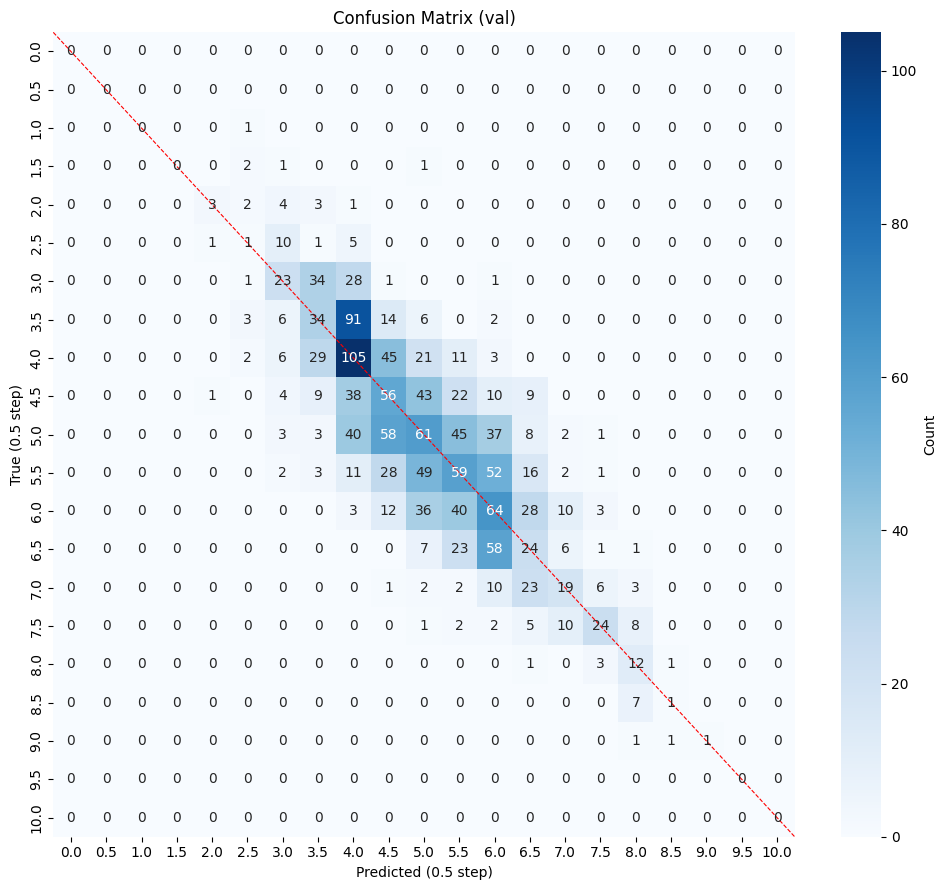


=== TEST ===
MAE 0.9177, MSE 1.4086, RMSE 1.1869, QWK 0.8320
edge_mae 0.6145, mid_mae 1.2773
edge_pred_ratio 0.9501, edge_true_ratio 0.5425
%|err|<=0.5: 33.36%, %|err|<=1.0: 60.75%, %|err|>1.0: 39.25%


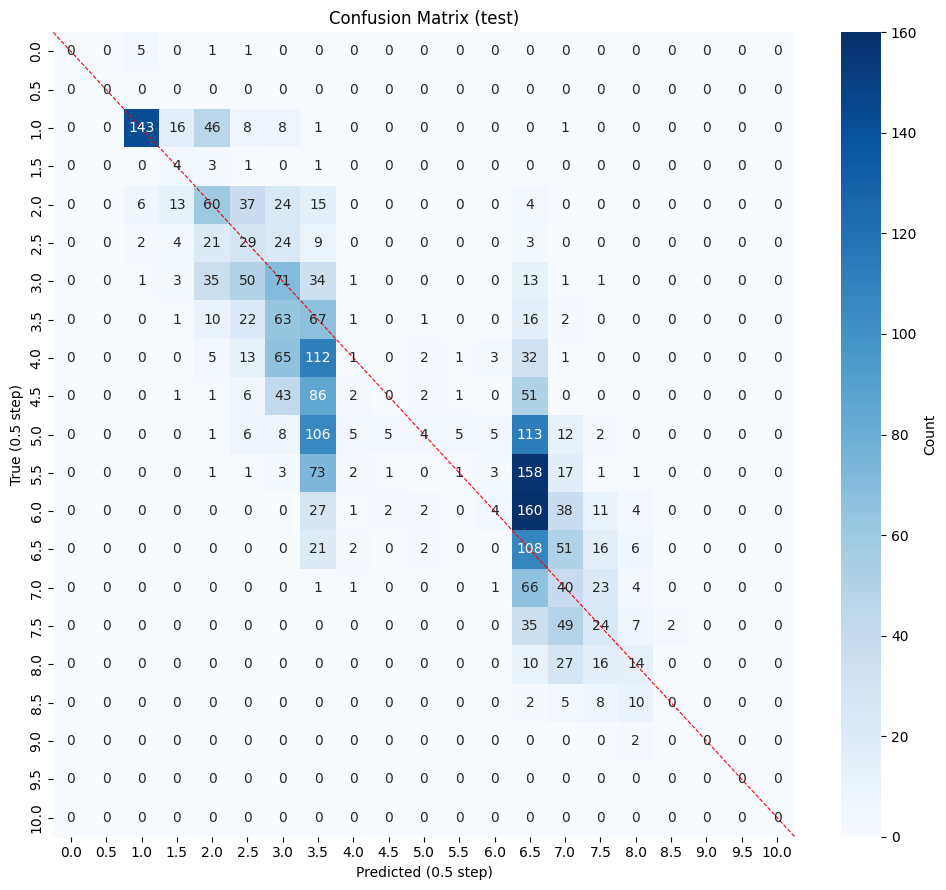

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from pathlib import Path

base = Path('/home/user06/Interspeech_2026/Model/Model/preds')
splits = {
    'val': pd.read_csv(base / 'val_predictions.csv'),
    'test': pd.read_csv(base / 'test_predictions.csv'),
}

edge_thr = 3.5
labels_int = np.arange(0, 21)         # 0..20 bins (0.5 step)
score_ticks = np.arange(0, 10.5, 0.5) # for axis labels

for name, df in splits.items():
    print(f"\n=== {name.upper()} ===")
    y_true = df['true_score'].to_numpy()
    y_pred = df['pred_score'].to_numpy()
    err = y_pred - y_true
    abs_err = np.abs(err)

    # Metrics
    mae = np.mean(abs_err)
    mse = np.mean(err**2)
    rmse = np.sqrt(mse)
    qwk = cohen_kappa_score(np.round(y_true*2).astype(int),
                            np.round(y_pred*2).astype(int),
                            weights='quadratic')
    edge_mask = (y_true <= edge_thr) | (y_true >= (10 - edge_thr))
    mid_mask = ~edge_mask
    edge_mae = np.mean(abs_err[edge_mask]) if edge_mask.any() else np.nan
    mid_mae = np.mean(abs_err[mid_mask]) if mid_mask.any() else np.nan
    edge_pred_ratio = ((y_pred <= edge_thr) | (y_pred >= (10 - edge_thr))).mean()
    edge_true_ratio = edge_mask.mean()

    pct_le_0_5 = (abs_err <= 0.5).mean()*100
    pct_le_1_0 = (abs_err <= 1.0).mean()*100
    pct_gt_1_0 = (abs_err > 1.0).mean()*100

    print(f"MAE {mae:.4f}, MSE {mse:.4f}, RMSE {rmse:.4f}, QWK {qwk:.4f}")
    print(f"edge_mae {edge_mae:.4f}, mid_mae {mid_mae:.4f}")
    print(f"edge_pred_ratio {edge_pred_ratio:.4f}, edge_true_ratio {edge_true_ratio:.4f}")
    print(f"%|err|<=0.5: {pct_le_0_5:.2f}%, %|err|<=1.0: {pct_le_1_0:.2f}%, %|err|>1.0: {pct_gt_1_0:.2f}%")

    # Binning to 0.5 and int labels
    true_bins = np.round(y_true * 2) / 2.0
    pred_bins = np.round(y_pred * 2) / 2.0
    true_lbl = np.round(true_bins * 2).astype(int)
    pred_lbl = np.round(pred_bins * 2).astype(int)

    cm = confusion_matrix(true_lbl, pred_lbl, labels=labels_int)

    plt.figure(figsize=(10, 9))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=score_ticks, yticklabels=score_ticks, cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted (0.5 step)')
    plt.ylabel('True (0.5 step)')
    plt.title(f'Confusion Matrix ({name})')
    plt.plot([0, len(labels_int)], [0, len(labels_int)], color='red', linestyle='--', linewidth=0.8)
    plt.tight_layout()
    plt.show()


In [20]:
import pandas as pd
from pathlib import Path

orig_path = Path('/home/user06/data/Speaking_VSTEP/Test_V2/with_instruction/unseen/train_split_with_questions_augment_edge.csv')
bal_path  = Path('/home/user06/data/Speaking_VSTEP/Test_V2/with_instruction/unseen/train_split_with_questions_augment_edge_balance.csv')

orig = pd.read_csv(orig_path)
bal  = pd.read_csv(bal_path)

bal_ids = set(bal['Candidate_ID'].astype(str))
missing = orig[~orig['Candidate_ID'].astype(str).isin(bal_ids)].copy()

out_dir = Path('/home/user06/Interspeech_2026/Model/Model/preds_new')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'samples_not_in_balance.csv'
missing.to_csv(out_path, index=False)

print(f"Orig total: {len(orig)}, Bal total: {len(bal)}, Missing: {len(missing)}")
print('Saved ->', out_path)
print(missing[['Candidate_ID','final']].head())


Orig total: 24223, Bal total: 15418, Missing: 6007
Saved -> /home/user06/Interspeech_2026/Model/Model/preds_new/samples_not_in_balance.csv
     Candidate_ID  final
4   AJC0904250009    7.0
5   AJC0904250010    6.5
18  AJC0904250034    7.0
20  AJC0904250036    3.5
23  AJC0904250039    7.5


In [18]:
import pandas as pd
from pathlib import Path

base = Path('/home/user06/Interspeech_2026/Model/Model/preds_new')
missing_path = base / 'samples_not_in_balance.csv'
bal_path = Path('/home/user06/data/Speaking_VSTEP/Test_V2/with_instruction/unseen/train_split_with_questions_augment_edge_balance.csv')
edge_thr = 3.0

missing = pd.read_csv(missing_path)
bal = pd.read_csv(bal_path)

edges = bal[(bal['final'] <= edge_thr) | (bal['final'] >= (10 - edge_thr))].copy()
combined = pd.concat([missing, edges], ignore_index=True)

combined.to_csv(missing_path, index=False)
print(f"Updated samples_not_in_balance.csv with edges from balance. New size: {len(combined)}")
print(combined['final'].value_counts().sort_index())


Updated samples_not_in_balance.csv with edges from balance. New size: 11107
final
0.0       19
0.5       99
1.0      130
1.5      370
2.0      290
2.5      802
3.0     2219
3.5     1340
6.5     1250
7.0     1928
7.5     1354
8.0      523
8.5      537
9.0      203
9.5       42
10.0       1
Name: count, dtype: int64


In [21]:
import pandas as pd
import ast
from pathlib import Path

csv_path = Path('/home/user06/Interspeech_2026/Model/Model/preds_new/samples_not_in_balance.csv')
out_path = Path('/home/user06/Interspeech_2026/Model/Model/preds_new/samples_not_in_balance_fixed.csv')

# Columns to process
list_cols = ['absolute_paths', 'text', 'question_type', 'Question']

# Load
df = pd.read_csv(csv_path)
print('Loaded:', len(df))

fixed_rows = []
num_fixed = 0
num_bad = 0

for _, row in df.iterrows():
    new_row = row.copy()
    lists = {}
    # Parse list-like columns if present
    for col in list_cols:
        if col in row:
            try:
                lists[col] = ast.literal_eval(row[col]) if isinstance(row[col], str) else row[col]
            except Exception:
                lists[col] = []
        else:
            lists[col] = None

    # Determine target length (expect 3 parts)
    target_len = 3
    abs_list = lists['absolute_paths'] if lists['absolute_paths'] is not None else []
    txt_list = lists['text'] if lists['text'] is not None else []
    qtype_list = lists['question_type'] if lists['question_type'] is not None else []
    ques_list = lists['Question'] if lists['Question'] is not None else []

    # If any list shorter than 3, pad by repeating the first available item
    def pad_list(lst):
        if lst is None:
            return None
        if not lst:
            return []
        while len(lst) < target_len:
            lst.append(lst[0])
        return lst[:target_len]

    orig_len = len(abs_list) if abs_list else 0
    abs_list = pad_list(abs_list)
    txt_list = pad_list(txt_list)
    qtype_list = pad_list(qtype_list)
    ques_list = pad_list(ques_list)

    if orig_len != target_len:
        num_fixed += 1

    # Update row
    if abs_list is not None:
        new_row['absolute_paths'] = str(abs_list)
    if txt_list is not None:
        new_row['text'] = str(txt_list)
    if qtype_list is not None:
        new_row['question_type'] = str(qtype_list)
    if ques_list is not None and len(ques_list) > 0:
        new_row['Question'] = str(ques_list)
    # num_samples update
    new_row['num_samples'] = target_len

    fixed_rows.append(new_row)

fixed_df = pd.DataFrame(fixed_rows)
fixed_df.to_csv(out_path, index=False)
print(f"Saved fixed file -> {out_path}")
print(f"Total fixed rows (not 3 parts originally): {num_fixed}")
print(fixed_df[['Candidate_ID','absolute_paths','text']].head())


Loaded: 6007
Saved fixed file -> /home/user06/Interspeech_2026/Model/Model/preds_new/samples_not_in_balance_fixed.csv
Total fixed rows (not 3 parts originally): 246
    Candidate_ID                                     absolute_paths  \
0  AJC0904250009  ['/home/user06/data/Speaking_VSTEP/Test_V2/SPE...   
1  AJC0904250010  ['/home/user06/data/Speaking_VSTEP/Test_V2/SPE...   
2  AJC0904250034  ['/home/user06/data/Speaking_VSTEP/Test_V2/SPE...   
3  AJC0904250036  ['/home/user06/data/Speaking_VSTEP/Test_V2/SPE...   
4  AJC0904250039  ['/home/user06/data/Speaking_VSTEP/Test_V2/SPE...   

                                                text  
0  [" Let's talk about going to a restaurant. 1. ...  
1  [" The kind of school I did go to as a child i...  
2  [" Oh, I very, very love going to a party beca...  
3  [' Do you think that mobile phone is green ver...  
4  [" Good morning, I'm ready for the test and le...  
